# Deteccio d'opinions - Supervisat
Max Villalba i Biel Sánchez  
_Processament del Llenguatge Humà - GIA_  
___

## Introducció

En aquesta pràctica desenvoluparem un detector d'opinions (positives i negatives) basat en el **Movie Reviews Corpus**. Primer, aplicarem un preprocessament adequat per a aquesta tasca. A continuació, utilitzarem el mètode de **bag of words** amb **CountVectorizer** per transformar les dades en un format que el model pugui processar.

Posteriorment, realitzarem un **grid search** sobre diferents models i paràmetres per seleccionar el que ofereixi la **major precisió** i alhora **minimitzi l’overfitting**.

Un cop seleccionat el model, l’avaluarem i analitzarem els errors més comuns que comet. En la segona part de la pràctica, compararem aquest model supervisat amb un model no supervisat.

In [2]:
# Fem tots els imports que seran necessaris pel codi

import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews as mr
import random
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import textwrap

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\maxvi\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


## Train i Validation

En aquest apartat definim els **identificadors de textos positius i negatius** per tal de poder realitzar l'**split** més fàcilment. Abans d'executar-lo, apliquem un **shuffle** per evitar problemes derivats de l'ordre original de les dades, tenint en compte que més endavant en farem un altre per barrejar definitivament positius i negatius. 

A continuació, realitzem una divisió **80/20** entre els conjunts de **train** i **validation**. Hem decidit escollir aquestes proporcions perquè considerem que són les més adequades per a la **mida del nostre corpus**. Finalment, ajuntem els textos positius i els negatius en un mateix conjunt per consolidar l'estructura de treball.

In [3]:
pos_ids = mr.fileids('pos')
neg_ids = mr.fileids('neg')

random.seed(42)
random.shuffle(pos_ids)
random.shuffle(neg_ids)

# Separació entre train i val tant per positius com per negatius
train_pos = pos_ids[:800]
val_pos = pos_ids[800:]

train_neg = neg_ids[:800]
val_neg = neg_ids[800:]

train_files = train_pos + train_neg
val_files = val_pos + val_neg

print(f"Entrenament: {len(train_files)} arxius ({len(train_pos)} pos, {len(train_neg)} neg)")
print(f"Validació: {len(val_files)} arxius ({len(val_pos)} pos, {len(val_neg)} neg)")

Entrenament: 1600 arxius (800 pos, 800 neg)
Validació: 400 arxius (200 pos, 200 neg)


## Preprocessament

En aquest apartat definim el preprocessament que rebran els textos abans de ser introduïts als models. El primer pas consisteix a agafar els textos en brut (**raw**) i crear els vectors **y**, on **1** representa l'opinió positiva i **0** representa una opinió negativa. A continuació, apliquem el **shuffle** que havíem mencionat anteriorment per barrejar els textos positius i negatius, i executem el preprocessament amb **CountVectorizer**. 

**CountVectorizer** té un paràmetre anomenat **max_features** el qual descriu la mida del diccionari amb el qual treballarem (bàsicament el nombre de columnes de la matriu que passarem al predictor). Per escollir el millor valor d'aquest hiperparàmetre hem decidit fer un explorat exhaustiu amb diversos valors i anar analitzant quina era l'accuracy obtinguda amb un model que fos senzill i ràpid (Hem escollit el **Naive Bayes**, ja que compleix totes dues característiques), el **pipeline** prova tots els valors que es veuen al vector i fa un total de 5 repeticions per cada valor per a saber la variància de cada un d'ells.

En la següent secció explicarem quin valor de **max_features** fem servir i el justificarem així com explicarem el preprocessat que fem a partir de **CountVectorizer**.

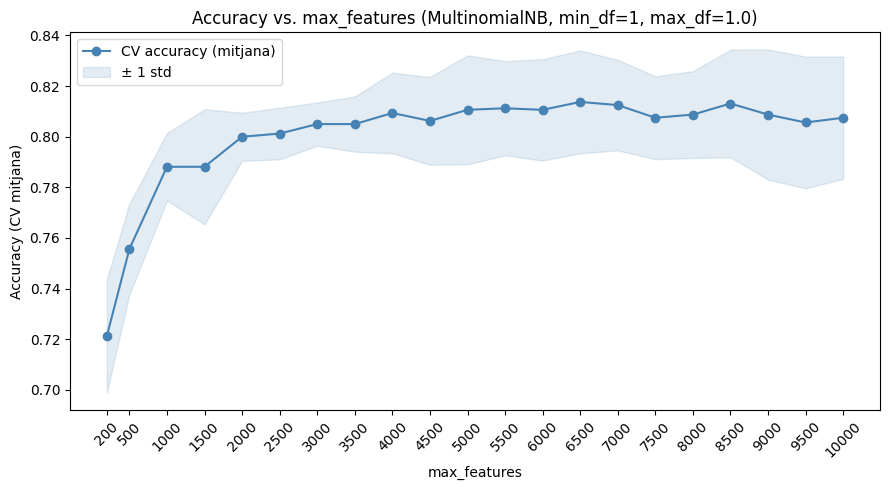

In [ ]:
# Dades
train_texts = [mr.raw(fileid) for fileid in train_files]
val_texts = [mr.raw(fileid) for fileid in val_files]

y_train = [1] * 800 + [0] * 800
y_val = [1] * 200 + [0] * 200

train_texts, y_train = shuffle(train_texts, y_train, random_state=42)
val_texts, y_val = shuffle(val_texts, y_val, random_state=42)

# Pipeline i GridSearch només sobre max_features
pipeline_nb = Pipeline([
    ('vec', CountVectorizer(stop_words='english', token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')),
    ('clf', MultinomialNB())
])

param_grid_vec = {
    'vec__max_features': [200, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000,6500, 7000,7500, 8000,8500, 9000,9500, 10000]
}

grid_vec = GridSearchCV(pipeline_nb, param_grid_vec, cv=5, scoring='accuracy', n_jobs=-1)
grid_vec.fit(train_texts, y_train)


best_nb_model = grid_vec.best_estimator_
train_acc_nb = best_nb_model.score(train_texts, y_train)
val_acc_nb = best_nb_model.score(val_texts, y_val)

results = pd.DataFrame(grid_vec.cv_results_)
x_vals = results['param_vec__max_features'].astype(int).values
y_vals = results['mean_test_score'].values

d2 = np.diff(y_vals, 2)
elbow_idx = np.argmax(d2) + 1 
elbow_x = x_vals[elbow_idx]
elbow_y = y_vals[elbow_idx]

# Gràfica
plt.figure(figsize=(9, 5))
plt.plot(
    x_vals,
    y_vals,
    marker='o',
    color='steelblue',
    label='CV accuracy (mitjana)'
)
plt.fill_between(
    x_vals,
    y_vals - results['std_test_score'].values,
    y_vals + results['std_test_score'].values,
    alpha=0.15,
    color='steelblue',
    label='± 1 std'
)
plt.xlabel('max_features')
plt.ylabel('Accuracy (CV mitjana)')
plt.title('Accuracy vs. max_features (MultinomialNB, min_df=1, max_df=1.0)')
plt.xticks(x_vals, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



## CountVectorizer

A la gràfica anterior es pot veure clarament com, a partir de les **2000 features**, sembla estabilitzar-se en un accuracy de **0.8**. Tot i això, hem decidit escollir unes **4000 features**, ja que sembla que hi ha un petit salt de millora respecte a les anteriors, i és a partir d’aquest punt on també el rang de confiança comença a augmentar molt, cosa que ens indica que molt possiblement, a partir d’aquest punt, hi haurà **overfitting**. Per tant, tot i que altres punts més endavant sembla que tinguin major accuracy, molt probablement, en provar-ho amb un nou conjunt de dades, es comporti pitjor degut al fet que presentaran aquest problema.

A part d’això, també li passem al **CountVectorizer** dos hiperparàmetres més: **stop_words** i **token_pattern**. El primer serveix per eliminar les **stop words** que estan en anglès (determinants, articles, etc.), ja que considerem que aquestes paraules aporten poca informació. Com que estem treballant amb un màxim de 4000 paraules diferents (**max_features**), preferim centrar-nos en altres que puguin ser més importants. El segon hiperparàmetre fa un filtratge de paraules i elimina les paraules de longitud inferior a dos (per eliminar algun error i coses així) i els **digits**, ja que ens vam fixar que la majoria eren anys i aquests aporten poca informació. Sí que es podria argumentar que alguns digits podrien aportar informació respecte a la nota que es pot donar a una pel·lícula, però la majoria d’aquests estan escrits amb text del tipus ('five stars' o 'nine out of ten').

Finalment, **CountVectorizer**, per si sol, ja passa tots els caràcters a minúscula i elimina els signes de puntuació. Així doncs, amb el preprocessat ja definit, obtenim la matriu que passarem als models en la següent secció.

In [16]:
# Vectoritzador final
best_max_features = 4000

vectorizer = CountVectorizer(
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b',
    max_features=best_max_features,
)

X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
print(f"Shape final de X_train: {X_train.shape}")

Shape final de X_train: (1600, 4000)


## Models i selecció d'hiperparàmetres

Hem definit un conjunt de quatre models diferents per realitzar les prediccions i determinar quin ofereix millors resultats. Els models seleccionats són: **Multinomial Naive Bayes**, **Regressió Logística**, **LinearSVC** i el **Perceptró**.

### Multinomial Naive Bayes
Aquest model és especialment eficaç quan es treballa amb el **Bag of Words** de CountVectorizer, ja que és molt ràpid i gestiona bé les **matrius sparse**. En el nostre cas, disposem d'una columna per cada paraula, fet que genera una matriu amb molts zeros perquè cada text només conté una petita part del vocabulari total. Per a la cerca d'hiperparàmetres, hem explorat diferents valors d'**alpha** (que actua com el suavitzat de Lidstone) i el **fit_prior** per decidir si les probabilitats de les classes han de ser uniformes o basades en l'entrenament.

### Regressió Logística
És un model ideal per a la classificació binària com la que ens ocupa. Per treballar correctament amb matrius sparse, hem seleccionat solvers específics compatibles. Com a hiperparàmetres, definim el paràmetre de regularització **C**, el tipus de **penalty** i el propi **solver**. També hem ajustat el nombre màxim d'iteracions per garantir la convergència del model sense incórrer en **overfitting**.

### SVM Lineal (LinearSVC)
Aquest model és molt eficient en espais de grans dimensions i funciona de manera òptima amb un nombre elevat de paraules. Hem ajustat el paràmetre **C** per controlar la regularització i hem explorat diferents funcions de pèrdua (**loss**). Així mateix, hem analitzat si és més convenient resoldre el problema mitjançant la formulació **dual** o la **primal**, a més de limitar el nombre d'iteracions.

### Perceptró
Similar a l'SVM lineal, el Perceptró és molt adequat per a aquest tipus de dades. Els hiperparàmetres explorats inclouen l'**alpha** (constant de regularització), el **penalty** (L1, L2 o cap), l'**eta0** (velocitat d'aprenentatge) i el nombre màxim d'iteracions. També hem incorporat l'**early stopping** per aturar l'entrenament si el model ja ha convergit.

### Entrenament i avaluació
Un cop definits els models, els entrenem amb el conjunt de **train** i guiem la cerca mitjançant la mètrica d'**accuracy**. Per a cada millor predictor obtingut, realitzem una prova amb el conjunt de **validació** per avaluar el nivell d'overfitting i generem la **matriu de confusió**. En el següent apartat, analitzarem quin és el model escollit i els motius de la decisió.

In [17]:
#Definim els models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Linear SVC": LinearSVC(),
    "Perceptron": Perceptron()
}

param_grids = {
    "Naive Bayes": {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
        'fit_prior': [True, False]
    },

    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000, 2000]
    },

    "Linear SVC": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'loss': ['hinge', 'squared_hinge'],
        'dual': [False, True],
        'max_iter': [1000, 2000, 5000]
    },

    "Perceptron": {
        'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
        'penalty': [None, 'l1', 'l2'],
        'max_iter': [1000, 2000, 5000],
        'eta0': [0.1, 0.01, 0.001],
        'early_stopping': [True, False]
    }
}

# Per cada model, l'entrenem amb el train i escollim el que millor accuracy.

for name, model in models.items():
    print(f"Buscant millors hiperparàmetres per: {name}...")
    
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    y_pred_val = best_model.predict(X_val)
    y_pred_train = best_model.predict(X_train)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    print(f"--- {name} ---")
    print(f"Millors hiperparàmetres: {grid.best_params_}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Gap (overfitting): {train_acc - val_acc:.4f}")
    
    print("Matriu de Confusió (validation):")
    print(confusion_matrix(y_val, y_pred_val))
    print("\n")

Buscant millors hiperparàmetres per: Naive Bayes...
--- Naive Bayes ---
Millors hiperparàmetres: {'alpha': 1.0, 'fit_prior': True}
Train accuracy: 0.9038
Validation accuracy: 0.8100
Gap (overfitting): 0.0938
Matriu de Confusió (validation):
[[169  31]
 [ 45 155]]


Buscant millors hiperparàmetres per: Logistic Regression...
--- Logistic Regression ---
Millors hiperparàmetres: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Train accuracy: 0.9769
Validation accuracy: 0.8600
Gap (overfitting): 0.1169
Matriu de Confusió (validation):
[[172  28]
 [ 28 172]]


Buscant millors hiperparàmetres per: Linear SVC...
--- Linear SVC ---
Millors hiperparàmetres: {'C': 0.001, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 1000}
Train accuracy: 0.9775
Validation accuracy: 0.8475
Gap (overfitting): 0.1300
Matriu de Confusió (validation):
[[164  36]
 [ 25 175]]


Buscant millors hiperparàmetres per: Perceptron...
--- Perceptron ---
Millors hiperparàmetres: {'alpha': 1e-05, 'early_

## Millor model:

Un cop fet l'entrenament i després de trobar els millors hiperparàmetres per cada model, seleccionarem el millor. Per triar el millor model buscarem aquell resultat que obtingui el millor equilibri entre **poc overfitting** i **accuracy elevada**.

Observant el que hem obtingut, podem veure que **Naive Bayes** tot i ser el model amb menys overfitting, és el que obté l'accuracy més baixa. De manera contraria, tot i que la **linear SVC** i el **perceptró** obtenen una accuracy molt elevada en el train, són els models amb més overfitting, indicant que es sobreajusten molt a les dades d'entrenament.

Es per aixó que triem la **regressió logística** (amb els millors paràmetres trobats), ja és el model que presenta el millor equilibri entre els dos aspectes.

A continuació, tornem a entrenar el model triat per tal d'obtenir els resultats finals i poder continuar amb els següents apartats.

In [5]:
best_model = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=1000)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

## Anàlisi dels resultats:

Començarem comentant els **resultats obtinguts**.

La matriu de confusió següent ens mostra els valors reals en relació als valors predits pel model. Podem veure que, en general, el model prediu prou bé si una opinió es positiva o negativa, i això es reflexa en que la gran proporció de valors es situen en la diagonal principal.

Únicament en 58 casos el model prediu de manera errònia, fet que estudiarem en el següent apartat d'anàlisi dels errors.

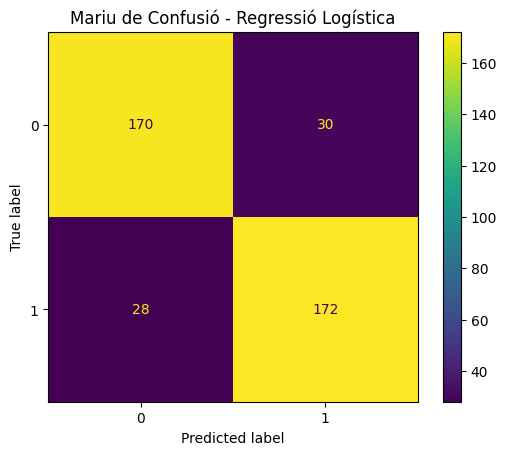

In [6]:
cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Mariu de Confusió - Regressió Logística")
plt.show()

Comencem ara a fer un **anàlisi dels errors**, on intentarem veure on i perquè el model falla en certes situacions.

In [7]:
errors = [i for i in range(len(y_val)) if y_val[i] != y_pred[i]]
error_texts = [val_texts[i] for i in errors]

print(f"Total d'errors: {len(errors)}")

fp_indices = [i for i in range(len(y_val)) if y_val[i] == 0 and y_pred[i] == 1]
fn_indices = [i for i in range(len(y_val)) if y_val[i] == 1 and y_pred[i] == 0]

fp_texts = [val_texts[i] for i in fp_indices]
fn_texts = [val_texts[i] for i in fn_indices]


print(f"    Falsos Positius (Real: Negativa, Predicció: Positiva): {len(fp_indices)}")
print(f"    Falsos Negatius (Real: Positiva, Predicció: Negativa): {len(fn_indices)}")

Total d'errors: 58
    Falsos Positius (Real: Negativa, Predicció: Positiva): 30
    Falsos Negatius (Real: Positiva, Predicció: Negativa): 28


Tal i com hem observat en la matriu de confusió, tenim un total de **58 errors**, dels cuals **30 són deguts a falsos positius** (la predicció diu que la opinió és positiva quan en realitat és negativa) i **28 són deguts a falsos negatius** (la predicció diu que la opinió és negativa quan en realitat és positiva).

Podem veure que la proporció de falsos positius i falsos negatius es bastant similar, indicant que el model **no presenta un biaix clar** cap a ninguna de les dues classes i, per tant, comet errors de manera **força equilibrada** entre opinions positives i negatives.

A continuació analitzarem quines han sigut les paraules més comunes en els errors.

Començarem fent un anàlisi general:

In [8]:
analyzer = vectorizer.build_analyzer()

# Funció auxiliar per trobar les n paraules més comunes en un text
def get_top_n_words(texts, n):
    words = []
    for text in texts:
        words.extend(analyzer(text))
    return Counter(words).most_common(n)

In [9]:
common_words = get_top_n_words(error_texts, 20)

print("Les 20 paraules més comunes en errors (Paraula => Vegades que apareix):")
for w, c in common_words:
    print(f"{w} => {c}")

Les 20 paraules més comunes en errors (Paraula => Vegades que apareix):
film => 328
movie => 141
like => 94
just => 82
time => 71
story => 66
good => 65
little => 53
people => 51
characters => 50
director => 46
character => 46
know => 44
plot => 44
scenes => 44
end => 43
films => 42
does => 42
make => 42
man => 41


Si observem amb detall les paraules que apareixen més en les opinions mal classificades, podem veure **tres fenòmens diferents**:
- En primer lloc tenim paraules que, degut al context en el que estem treballant, és normal que **apareguin més vegades**. Per exemple, paraules com *film*, *movie* o *story* són paraules que, al estar treballant amb **opinons de pel·licules**, té lògica que apareguin tant en opinions positives com negatives. Per tant, també té sentit que apareguin més vegades que la resta de paraules en els exemples mal classificats.

- En segon lloc ens trobem amb **paraules enganyoses**: paraules que *sembla* que determinin el sentiment d'un text, però que no te perquè. Per exemple, paraules com *good* o *like* podrien fer pensar al model que es tracta d'una opinió positiva, mentre que paraules com *little* podrien fer pensar que és una opinió negativa, i això no és sempre així.

- Per últim, és interessant veure que altres paraules com *know*, *does* o *make* apareixen també en molts textos mal classificats, tot i que no sembla que hi hagi un motiu aparent.

A continuació mirarem un altre cop les paraules més comunes en els errors, però aquesta vegada ho separarem entre **falsos positius** i **falsos negatius**:

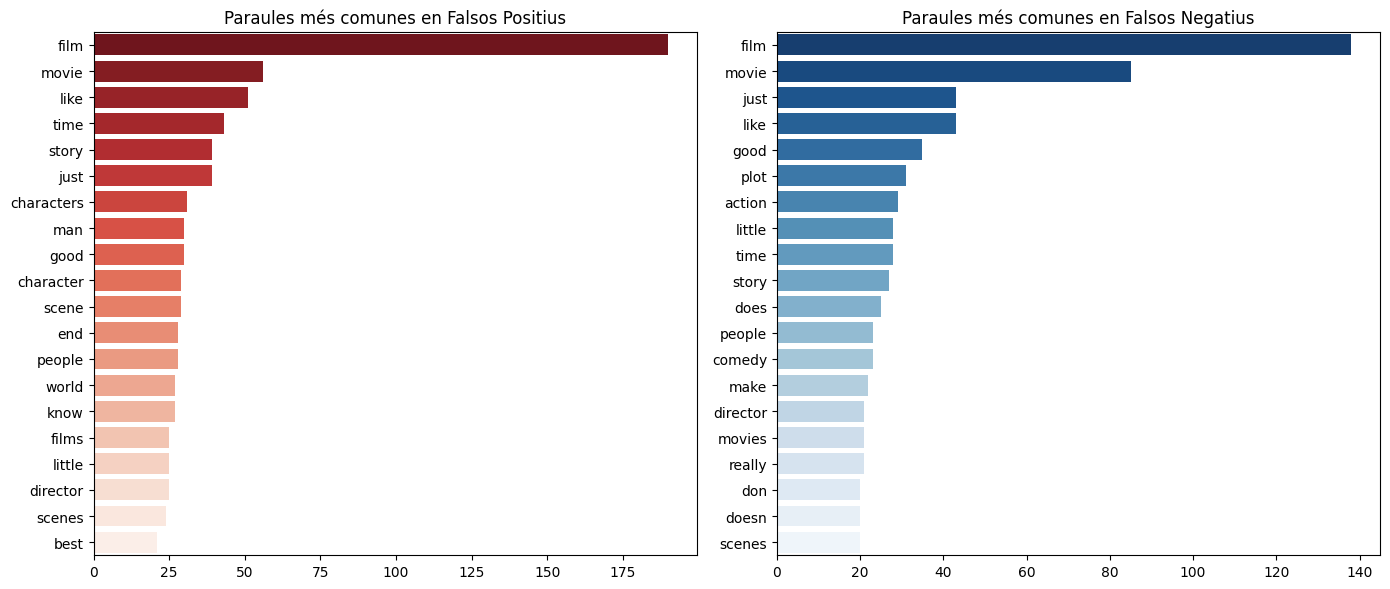

In [12]:
top_fp = get_top_n_words(fp_texts, 20)
top_fn = get_top_n_words(fn_texts, 20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=[c for w, c in top_fp], y=[w for w, c in top_fp], ax=axes[0], palette="Reds_r")
axes[0].set_title("Paraules més comunes en Falsos Positius")

sns.barplot(x=[c for w, c in top_fn], y=[w for w, c in top_fn], ax=axes[1], palette="Blues_r")
axes[1].set_title("Paraules més comunes en Falsos Negatius")

plt.tight_layout()
plt.show()

Podem veure que el patró general tant en falsos positius com en falsos negatius és **molt semblant** entre ells. Es pot observar el mateix fenòmen que teniem abans: paraules com *film* i *movie* apareixen molt sovint en els dos casos.

Curiosament, i a diferència del que semblava en l'anterior apartat, la paraula *good* apareix més cops en els falsos negatius que en els falsos positius. És a dir, quan el model "veu" la paraula *good*, es més probable que la classifiqui com a opinió negativa. En el cas de la paraula *like*, la tenim força present en els dos casos i, si parlem de la paraula *little*, aquesta està bastant més present en els falsos negatius, tal i com s'espera.

En el següent apartat ens centrarem en la **longitud** dels textos:

Longitud mitjana en errors: 302.72 (Min: 85, Max: 877)
Longitud mitjana en encerts: 323.19 (Min: 57, Max: 1086)


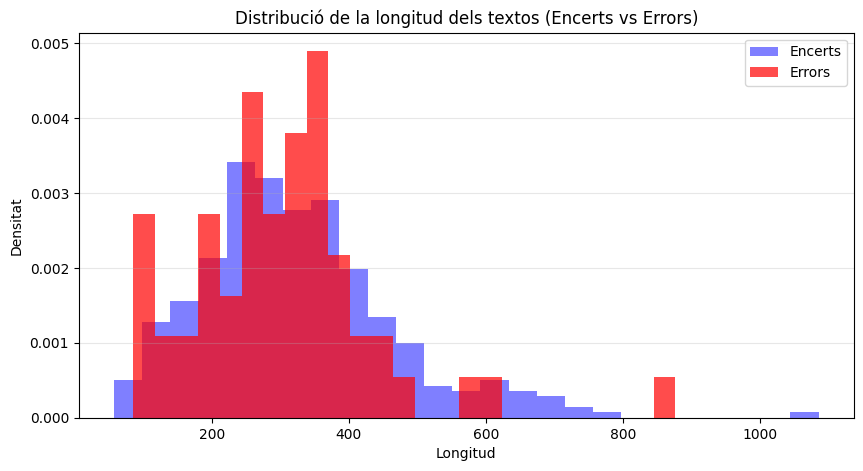

In [15]:
lengths_errors = [len(analyzer(t)) for t in error_texts]
correct_texts = [val_texts[i] for i in range(len(y_val)) if y_val[i] == y_pred[i]]
lengths_correct = [len(analyzer(t)) for t in correct_texts]

print(f"Longitud mitjana en errors: {np.mean(lengths_errors):.2f} (Min: {np.min(lengths_errors)}, Max: {np.max(lengths_errors)})")
print(f"Longitud mitjana en encerts: {np.mean(lengths_correct):.2f} (Min: {np.min(lengths_correct)}, Max: {np.max(lengths_correct)})")

plt.figure(figsize=(10, 5))
plt.hist(lengths_correct, bins=25, alpha=0.5, label='Encerts', color='blue', density=True)
plt.hist(lengths_errors, bins=25, alpha=0.7, label='Errors', color='red', density=True)
plt.title("Distribució de la longitud dels textos (Encerts vs Errors)")
plt.xlabel("Longitud")
plt.ylabel("Densitat")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Si mirem el gràfic podem veure que els errors s'ubiquen principalment en **longituds petites**, mentre que els encerts, tot i estar presents en moltes longituds, hi ha una proporció important d'aquests situats en **longituds força grans**. Això indica que, en general, el model sol classificar correctament les opinions llargues mentre que sol fallar les opinions curtes, ja que no té tant "context" per determinar si una opinió és positiva o negativa.

Per acabar, anem a mirar alguns exemples d'opinions classificades incorrectament. Agafarem 5 exemples per simplificar:

In [23]:
for i in errors[:5]:
    real_label = "Positiva" if y_val[i] == 1 else "Negativa"
    pred_label = "Positiva" if y_pred[i] == 1 else "Negativa"
    error_type = "Fals Negatiu" if y_val[i] == 1 else "Falso Positiu"
    
    print(f"{error_type} (Real: {real_label} | Predicció: {pred_label})")
    print("-" * 50)
    # Mostrem els primers 300 caràcters
    print(textwrap.fill(val_texts[i][:300] + "...", width=80))
    print("=" * 50)

Fals Negatiu (Real: Positiva | Predicció: Negativa)
--------------------------------------------------
notice : this is a review and analysis of exotica .  the first part of this
piece is the review , the second part contains some analysis of the movie which
might be construed as spoilers .  if you have not seen the movie and after
reading the first part you intend to do so , then save the second par...
Fals Negatiu (Real: Positiva | Predicció: Negativa)
--------------------------------------------------
jacques tati's 1953 classic " les vacances de m . hulot " ( also known as " mr .
hulot's vacation , " in english ) ought to be the textbook on how to do non ?
dialogue comedy in film .  the characters hardly ever speak to each other
directly , and the film operates on the paper ? thin premise that m...
Fals Negatiu (Real: Positiva | Predicció: Negativa)
--------------------------------------------------
cinematically speaking , gordon parks' original 1971 _shaft_ is not a great film
. 

Analitzant els exemples podem veure una gran varietat de casos:
- En general, les opinions positives classificades incorrectament com a negatives mostren la presencia de parts **expresades en negatiu**: com per exemple "*if you have not seen the movie...*", "*the characters hardly ever speak to each other directly...*" o "*_shaft_ is not a great film. ...*". Aquestes expressions poden fer dubtar al model resultant en una incorrecta classificació.

- Pel cas de les opinions negatives classificades incorrectament com a positives, podem veure que de manera semblant hi ha parts del text que poden fer que el model predigui positiu malament, com per exemple "*necessary part of doing any job well...*". Altres textos, com l'últim exemple mostrat, curiosament és classificat com a positiu tot i ser clarament negatiu. Potser l'ús d'adjectius de manera continuada fa que el model es pensi que la opinió és positiva.

In [2]:
from textserver import TextServer

In [ ]:
ts = TextServer('max.villalba', 'passwd', 'senses') 
ts.senses("L'Arnau té un gos. Se l'estima molt.")

[[["L'Arnau", "l'arnau", 'NP00V00', 'noun', 'N/A'],
  ['té', 'té', 'VBZ', 'verb', 'N/A'],
  ['un', 'un', 'VBN', 'verb', 'N/A'],
  ['gos', 'gos', 'NNS', 'noun', 'N/A'],
  ['.', '.', 'Fp', 'punctuation', 'N/A']],
 [['Se', 'se', 'NP00SP0', 'noun', '13832841-n'],
  ["l'estima", "l'estima", 'NN', 'noun', 'N/A'],
  ['molt', 'molt', 'VB', 'verb', '00009147-v'],
  ['.', '.', 'Fp', 'punctuation', 'N/A']]]

In [4]:
pos_ids = mr.fileids('pos')
neg_ids = mr.fileids('neg')

In [5]:
train_n = [mr.raw(fileid) for fileid in neg_ids[:5]]
print(train_n)

train_p = [mr.raw(fileid) for fileid in pos_ids[:5]]
print(train_p)

['plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience memb

In [6]:
from nltk.tokenize import sent_tokenize
l = []
l_n = []
for x in range(5):

    text = train_p[x]
    frases = sent_tokenize(text)
    primera_frase = frases[0]
    l.append(primera_frase)


print(l)

for x in range(5):

    text = train_n[x]
    frases = sent_tokenize(text)
    primera_frase = frases[0]
    l_n.append(primera_frase)


print(l_n)

["films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before .", "every now and then a movie comes along from a suspect studio , with every indication that it will be a stinker , and to everybody's surprise ( perhaps even the studio ) the film becomes a critical darling .", "you've got mail works alot better than it deserves to .", ' " jaws " is a rare film that grabs your attention before it shows you a single image on screen .', "moviemaking is a lot like being the general manager of an nfl team in the post-salary cap era -- you've got to know how to allocate your resources ."]
['plot : two teen couples go to a church party , drink and then drive .', "the happy bastard's quick movie review \ndamn that y2k bug .", 'it is movies like these that make a jaded movie viewer thankful for t

In [14]:
df = ts.senses(l[0], pandas=True)
df2 = ts.senses(l[1], pandas=True)

In [18]:
from nltk.corpus import wordnet as wn
import pandas as pd

def convert_synset_safe(s):
    if pd.isna(s):        # Ignora NA
        return None
    try:
        offset, pos = s.split('-')   # "123-n" -> ["123", "n"]
        return wn.synset_from_pos_and_offset(pos, int(offset))
    except:
        return None  # Si hi ha algun error, també retorna None

# Aplica la funció a la columna
df['synset_obj'] = df['synset'].apply(convert_synset_safe)
df2['synset_obj'] = df2['synset'].apply(convert_synset_safe)

In [20]:
# Funció per obtenir la definició de manera segura
def get_definition(syn):
    if syn is None:    # Ignora les files NA
        return None
    return syn.definition()

# Afegeix la columna amb les definicions
df['definition'] = df['synset_obj'].apply(get_definition)
df2['definition'] = df2['synset_obj'].apply(get_definition)

df

,forma,lema,tag,pos,synset,synset_obj,definition
0,films,film,NNS,noun,06613686-n,Synset('movie.n.01'),a form of entertainment that enacts a story by...
1,adapted,adapt,VBD,verb,00299580-v,Synset('adapt.v.01'),"make fit for, or change to suit a new purpose"
2,from,from,IN,preposition,N/A,None,None
3,comic,comic,JJ,adjective,01265308-a,Synset('amusing.s.02'),arousing or provoking laughter
4,books,book,NNS,noun,02870092-n,Synset('book.n.02'),physical objects consisting of a number of pag...
5,have,have,VBP,verb,00065639-v,Synset('suffer.v.02'),undergo (as of injuries and illnesses)
6,had,have,VBD,verb,00065639-v,Synset('suffer.v.02'),undergo (as of injuries and illnesses)
7,plenty_of,plenty_of,DT,determiner,N/A,None,None
8,success,success,NN,noun,00063652-n,Synset('success.n.02'),an attainment that is successful
9,",",",",Fc,punctuation,N/A,None,None


In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bsanc\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
pos_files = mr.fileids('pos')[:5]
neg_files = mr.fileids('neg')[:5]

pos_sents = [mr.sents(f)[0] for f in pos_files]
neg_sents = [mr.sents(f)[0] for f in neg_files]

def desambigua_frase(frase, i):
    print(f"Frase {i}: {' '.join(frase)}")
    for paraula in frase:
        synset = nltk.wsd.lesk(frase, paraula)
        if synset:
            print(f"  {paraula}: {synset.name()} ({synset.definition()})")
        else:
            print(f"  {paraula}: N/A")

print("FRASES POSITIVES")
i = 1
for frase in pos_sents:
    desambigua_frase(frase, i)
    i += 1

print("\nFRASES NEGATIVES")
i = 1
for frase in neg_sents:
    desambigua_frase(frase, i)
    i += 1

FRASES POSITIVES
Frase 1: films adapted from comic books have had plenty of success , whether they ' re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there ' s never really been a comic book like from hell before .
  films: movie.n.01 (a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement)
  adapted: adapt.v.01 (make fit for, or change to suit a new purpose)
  from: N/A
  comic: comic.a.02 (of or relating to or characteristic of comedy)
  books: record.n.05 (a compilation of the known facts regarding something or someone)
  have: have.v.01 (have or possess, either in a concrete or an abstract sense)
  had: have.v.01 (have or possess, either in a concrete or an abstract sense)
  plenty: batch.n.02 ((often followed by `of') a large number or amount or extent)
  of: N/A
  success: success.n.03 (a state of prosperity or fame)
  ,: N/A
  whether